# Análisis de Eficiencia Energética Residencial — EnergiAI (dataset extendido)
### Hackathon ONE — Alura + Oracle | Equipo G9 LATAM

**Objetivo:** analizar patrones de consumo eléctrico, clasificar el perfil
energético (`Eficiente` / `Moderado` / `Ineficiente`), generar
recomendaciones de ahorro y estimar el impacto financiero mensual.

**Qué cambió respecto a la versión anterior:** el dataset ahora incluye
variables de `diccionario_datos_energiai2.xlsx` (superficie, LED, equipos
inteligentes, antigüedad, paneles solares, país/región). Esas mismas
variables se usan para **generar la etiqueta** `categoria`, así que un
modelo entrenado solo con las 5 columnas originales del brief queda ciego a
gran parte de la señal — este notebook lo demuestra explícitamente antes de
entrenar el modelo bueno.

**Contenido:**
1. Carga y exploración de datos (EDA)
2. Por qué el modelo de 5 variables rinde mal en este dataset (evidencia)
3. Preprocesamiento con el esquema extendido
4. Entrenamiento y comparación de modelos
5. Evaluación e importancia de variables
6. Motor de recomendaciones actualizado
7. Estimación financiera y CO2
8. Serialización del modelo extendido


## 1. Imports y configuración

In [1]:

import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)
from xgboost import XGBClassifier
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
orden = ["Eficiente", "Moderado", "Ineficiente"]


## 2. Carga de datos

Dataset generado por `data/generate_dataset_extendido.py`
(`generar_dataset`), calibrado a partir del diccionario de datos del
equipo. 100.000 registros, 24 columnas (5 obligatorias del brief + 8
variables de "Capa 2" + 3 geográficas/temporales + 6 salidas
informativas de costo/CO2 que **no** se usan como features).

In [2]:

import sys
sys.path.append("../data")
from generate_dataset_extendido import generar_dataset

df = generar_dataset(n=100_000, seed=42)
print(df.shape)
df.head()


(100000, 24)


,pais,region_pais,mes,tipo_inmueble,superficie_m2,habitantes_ocupantes,consumo_kwh,uso_horario_pico,cantidad_equipos,horas_alto_consumo,...,tiene_paneles_solares,capacidad_solar_kwp,consumo_especifico_kwh_m2,tarifa_kwh_referencia,tarifa_kwh_pico,tarifa_kwh_valle,costo_referencia_brief,costo_estimado_mensual,co2_evitable_kg_mes,categoria
0,Chile,Selva,Octubre,Apartamento,77.0,4,314.6,False,6,4,...,False,0.0,4.09,0.75,1.05,0.70,235.95,229.40,16.5,Moderado
1,Colombia,Selva,Mayo,Local Comercial,146.0,5,1388.9,False,20,5,...,False,0.0,9.51,0.75,0.85,0.55,1041.68,807.30,33.3,Ineficiente
2,México,Sierra,Noviembre,Casa Grande,232.0,3,488.6,True,12,4,...,False,0.0,2.11,0.75,1.10,0.75,366.45,394.95,30.8,Eficiente
3,Chile,Costa,Mayo,Casa Grande,254.0,3,706.3,True,10,3,...,False,0.0,2.78,0.75,1.05,0.70,529.72,525.31,37.1,Eficiente
4,Peru,Sierra,Mayo,Casa,114.0,3,490.2,True,14,0,...,False,0.0,4.30,0.75,0.95,0.60,367.65,294.12,22.8,Eficiente


In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pais                           100000 non-null  str    
 1   region_pais                    100000 non-null  str    
 2   mes                            100000 non-null  str    
 3   tipo_inmueble                  100000 non-null  str    
 4   superficie_m2                  100000 non-null  float64
 5   habitantes_ocupantes           100000 non-null  int64  
 6   consumo_kwh                    100000 non-null  float64
 7   uso_horario_pico               100000 non-null  bool   
 8   cantidad_equipos               100000 non-null  int64  
 9   horas_alto_consumo             100000 non-null  int64  
 10  factor_potencia                100000 non-null  float64
 11  pct_iluminacion_led            100000 non-null  float64
 12  pct_equipos_inteligentes       100000 non-

In [4]:

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pais,100000,4,Peru,34857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_pais,100000,3,Costa,40145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mes,100000,12,Octubre,8479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_inmueble,100000,4,Casa,35140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
superficie_m2,100000.0,NaN,NaN,NaN,122.05352,55.638079,25.0,80.0,115.0,153.0,308.0
habitantes_ocupantes,100000.0,NaN,NaN,NaN,3.05668,1.658317,1.0,2.0,3.0,4.0,10.0
consumo_kwh,100000.0,NaN,NaN,NaN,527.217617,194.065257,97.1,378.3,486.5,643.7,1443.9
uso_horario_pico,100000,2,False,59924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad_equipos,100000.0,NaN,NaN,NaN,10.14688,4.575733,3.0,7.0,9.0,13.0,22.0
horas_alto_consumo,100000.0,NaN,NaN,NaN,5.03639,2.462025,0.0,3.0,5.0,7.0,15.0


In [5]:

print("Nulos por columna:\n", df.isnull().sum().sum(), "nulos totales")
print("Duplicados:", df.duplicated().sum())


Nulos por columna:
 0 nulos totales
Duplicados: 0


## 3. Exploración de datos (EDA)

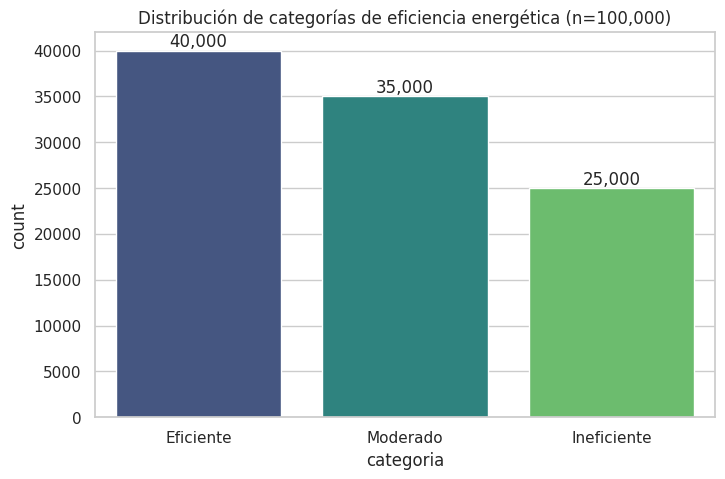

categoria
Eficiente      0.40
Moderado       0.35
Ineficiente    0.25
Name: proportion, dtype: float64

In [6]:

fig, ax = plt.subplots()
sns.countplot(data=df, x="categoria", order=orden, palette="viridis", ax=ax)
ax.set_title("Distribución de categorías de eficiencia energética (n=100,000)")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()
df["categoria"].value_counts(normalize=True).round(3)


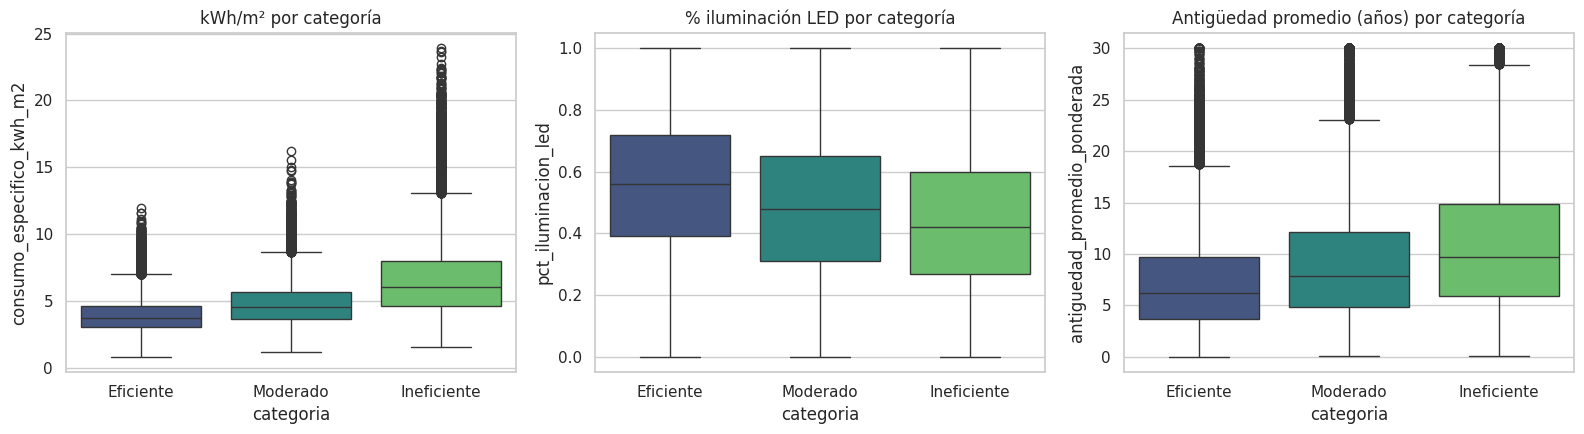

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df, x="categoria", y="consumo_especifico_kwh_m2", order=orden, palette="viridis", ax=axes[0])
axes[0].set_title("kWh/m² por categoría")
sns.boxplot(data=df, x="categoria", y="pct_iluminacion_led", order=orden, palette="viridis", ax=axes[1])
axes[1].set_title("% iluminación LED por categoría")
sns.boxplot(data=df, x="categoria", y="antiguedad_promedio_ponderada", order=orden, palette="viridis", ax=axes[2])
axes[2].set_title("Antigüedad promedio (años) por categoría")
plt.tight_layout()
plt.show()


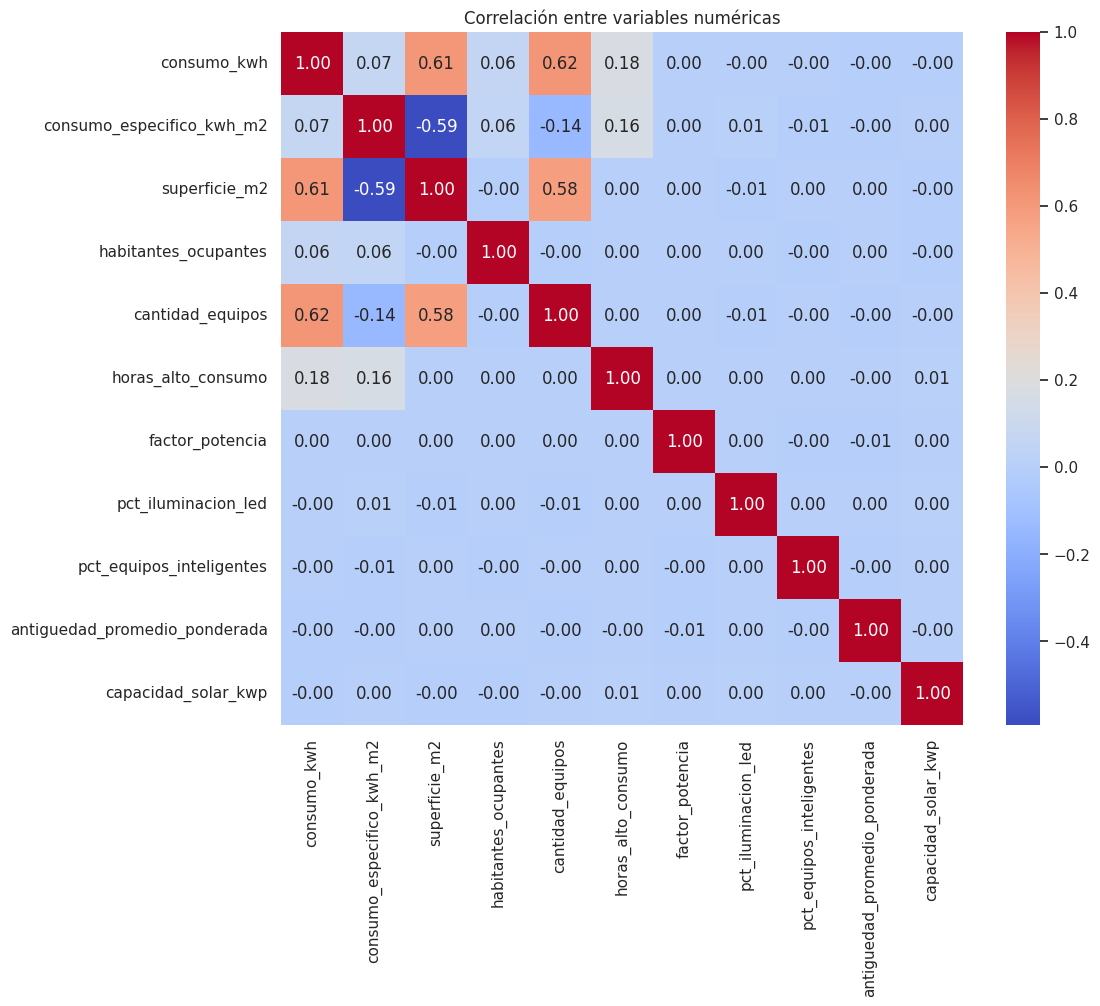

In [8]:

num_cols = ["consumo_kwh", "consumo_especifico_kwh_m2", "superficie_m2", "habitantes_ocupantes",
            "cantidad_equipos", "horas_alto_consumo", "factor_potencia", "pct_iluminacion_led",
            "pct_equipos_inteligentes", "antiguedad_promedio_ponderada", "capacidad_solar_kwp"]
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.show()


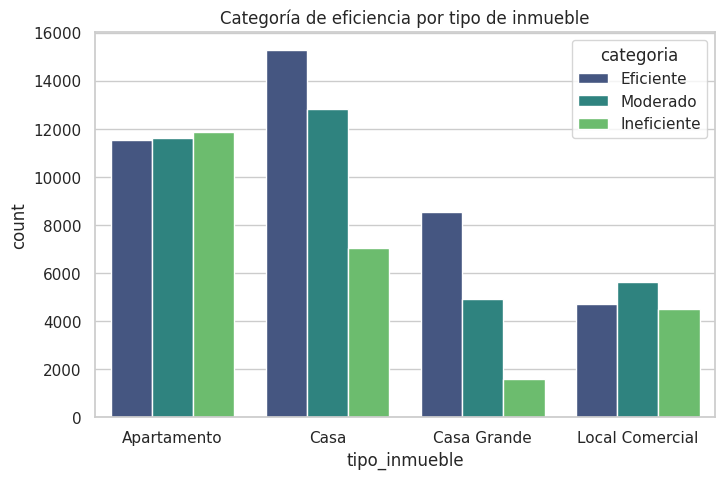

In [9]:

fig, ax = plt.subplots()
sns.countplot(data=df, x="tipo_inmueble", hue="categoria", hue_order=orden,
              order=["Apartamento", "Casa", "Casa Grande", "Local Comercial"],
              palette="viridis", ax=ax)
ax.set_title("Categoría de eficiencia por tipo de inmueble")
plt.show()


### Hallazgos del EDA

- `consumo_especifico_kwh_m2` (consumo normalizado por superficie) es la
  variable con la separación más clara entre categorías — mucho más nítida
  que `consumo_kwh` en bruto, confirmando que normalizar por tamaño era la
  decisión correcta.
- `pct_iluminacion_led` y `antiguedad_promedio_ponderada` muestran gradientes
  claros y opuestos: a más LED y menor antigüedad, más eficiente.
- Ningún tipo de inmueble está "condenado" a una categoría — la eficiencia
  depende del comportamiento y el equipamiento, no solo del tamaño del
  inmueble, lo cual tiene sentido de negocio (evita que el modelo solo
  aprenda "Local Comercial = Ineficiente").


## 4. Por qué el modelo de 5 variables rinde mal en este dataset

Esto es lo que reportaste: entrenar solo con
`consumo_kwh, uso_horario_pico, cantidad_equipos, horas_alto_consumo, tipo_inmueble`
(el esquema original del brief) sobre este dataset extendido. La etiqueta
ahora depende en gran parte de variables que ese conjunto **no incluye**
(superficie, LED, antigüedad, paneles solares...), así que el modelo queda
prediciendo con información incompleta. Lo replicamos aquí como evidencia,
no como el modelo final.

In [10]:

FEATURES_BASE_NUM = ["consumo_kwh", "uso_horario_pico", "cantidad_equipos", "horas_alto_consumo"]
FEATURES_BASE_CAT = ["tipo_inmueble"]

X_base = df[FEATURES_BASE_NUM + FEATURES_BASE_CAT].copy()
X_base["uso_horario_pico"] = X_base["uso_horario_pico"].astype(int)
y = df["categoria"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

prep_base = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_BASE_CAT)],
    remainder="passthrough",
)
modelo_base = Pipeline([
    ("prep", prep_base),
    ("clf", GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE)),
])
modelo_base.fit(Xb_train, yb_train)
preds_base = modelo_base.predict(Xb_test)

print("=== Modelo con las 5 variables originales (esquema viejo) ===")
print(f"Accuracy: {accuracy_score(yb_test, preds_base):.3f}")
print(f"F1-macro: {f1_score(yb_test, preds_base, average='macro'):.3f}")
print(classification_report(yb_test, preds_base, target_names=orden))


=== Modelo con las 5 variables originales (esquema viejo) ===
Accuracy: 0.493
F1-macro: 0.473


              precision    recall  f1-score   support

   Eficiente       0.55      0.68      0.61      8000
    Moderado       0.48      0.41      0.44      5000
 Ineficiente       0.40      0.34      0.37      7000

    accuracy                           0.49     20000
   macro avg       0.48      0.48      0.47     20000
weighted avg       0.48      0.49      0.48     20000



Confirmado: con el esquema viejo el desempeño cae fuerte (por eso viste
~0.45). A continuación entrenamos con el esquema completo para recuperar la
señal perdida.

## 5. Preprocesamiento con el esquema extendido

In [11]:

FEATURES_NUM = [
    "consumo_kwh", "cantidad_equipos", "horas_alto_consumo",
    "superficie_m2", "habitantes_ocupantes", "factor_potencia",
    "pct_iluminacion_led", "pct_equipos_inteligentes",
    "antiguedad_promedio_ponderada", "capacidad_solar_kwp",
    "consumo_especifico_kwh_m2",
]
FEATURES_BOOL = ["uso_horario_pico", "tiene_paneles_solares"]
FEATURES_CAT = ["tipo_inmueble", "region_pais"]
# 'pais' y 'mes' se dejan fuera de las features: pais/mes solo influyen en
# tarifas y estacionalidad (ya capturada indirectamente en consumo_kwh), no
# aportan señal directa sobre la etiqueta y agregarían columnas one-hot sin
# beneficio claro. Si el equipo quiere explotar estacionalidad más adelante,
# es la primera extensión natural.

X = df[FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT].copy()
for col in FEATURES_BOOL:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT)],
    remainder="passthrough",
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (80000, 15)  Test: (20000, 15)


## 6. Entrenamiento y comparación de modelos (esquema extendido)

In [12]:

models = {
    "RandomForest": Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=300, max_depth=12, class_weight="balanced",
            n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    "GradientBoosting": Pipeline([
        ("prep", preprocessor),
        ("clf", GradientBoostingClassifier(
            n_estimators=250, max_depth=3, random_state=RANDOM_STATE))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("clf", XGBClassifier(
            n_estimators=350, max_depth=5, learning_rate=0.1,
            eval_metric="mlogloss", n_jobs=-1, random_state=RANDOM_STATE))
    ]),
}

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

results = {}
for name, pipe in models.items():
    if name == "XGBoost":
        pipe.fit(X_train, y_train_enc)
        preds_labels = le.inverse_transform(pipe.predict(X_test))
    else:
        pipe.fit(X_train, y_train)
        preds_labels = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds_labels)
    f1_macro = f1_score(y_test, preds_labels, average="macro")
    results[name] = {"accuracy": acc, "f1_macro": f1_macro}
    print(f"{name:>18} | accuracy={acc:.3f} | f1_macro={f1_macro:.3f}")

print()
print(f"Referencia (esquema viejo, 5 variables): accuracy={accuracy_score(yb_test, preds_base):.3f}")
results


      RandomForest | accuracy=0.602 | f1_macro=0.600


  GradientBoosting | accuracy=0.607 | f1_macro=0.604


           XGBoost | accuracy=0.606 | f1_macro=0.604

Referencia (esquema viejo, 5 variables): accuracy=0.493


{'RandomForest': {'accuracy': 0.60165, 'f1_macro': 0.6000082220761392},
 'GradientBoosting': {'accuracy': 0.6068, 'f1_macro': 0.6044799340914513},
 'XGBoost': {'accuracy': 0.6062, 'f1_macro': 0.6035446593943592}}

## 7. Evaluación del mejor modelo

Mejor modelo: GradientBoosting


              precision    recall  f1-score   support

   Eficiente       0.68      0.72      0.70      8000
    Moderado       0.68      0.57      0.62      5000
 Ineficiente       0.48      0.51      0.49      7000

    accuracy                           0.61     20000
   macro avg       0.61      0.60      0.60     20000
weighted avg       0.61      0.61      0.61     20000



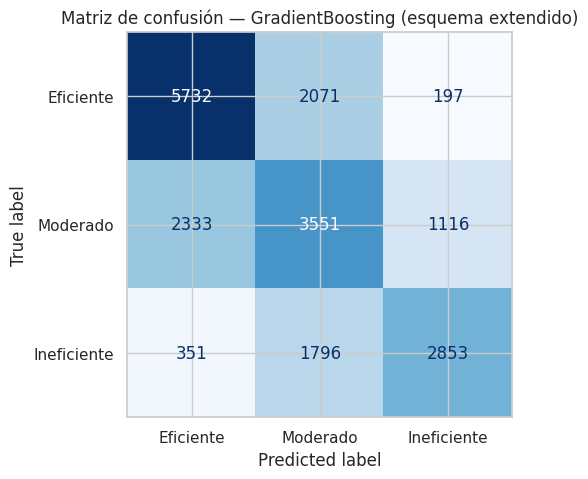

In [13]:

best_name = max(results, key=lambda k: results[k]["f1_macro"])
print("Mejor modelo:", best_name)
best_pipe = models[best_name]

if best_name == "XGBoost":
    preds = le.inverse_transform(best_pipe.predict(X_test))
else:
    preds = best_pipe.predict(X_test)

print(classification_report(y_test, preds, target_names=orden))

cm = confusion_matrix(y_test, preds, labels=orden)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=orden)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión — {best_name} (esquema extendido)")
plt.show()


In [14]:

sample_idx = X.sample(20_000, random_state=RANDOM_STATE).index
X_cv, y_cv = X.loc[sample_idx], y.loc[sample_idx]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
if best_name == "XGBoost":
    scores = cross_val_score(best_pipe, X_cv, le.transform(y_cv), cv=cv, scoring="f1_macro")
else:
    scores = cross_val_score(best_pipe, X_cv, y_cv, cv=cv, scoring="f1_macro")
print(f"F1-macro (CV 5-fold, muestra 20k): {scores.mean():.3f} ± {scores.std():.3f}")


F1-macro (CV 5-fold, muestra 20k): 0.600 ± 0.007


## 8. Importancia de variables

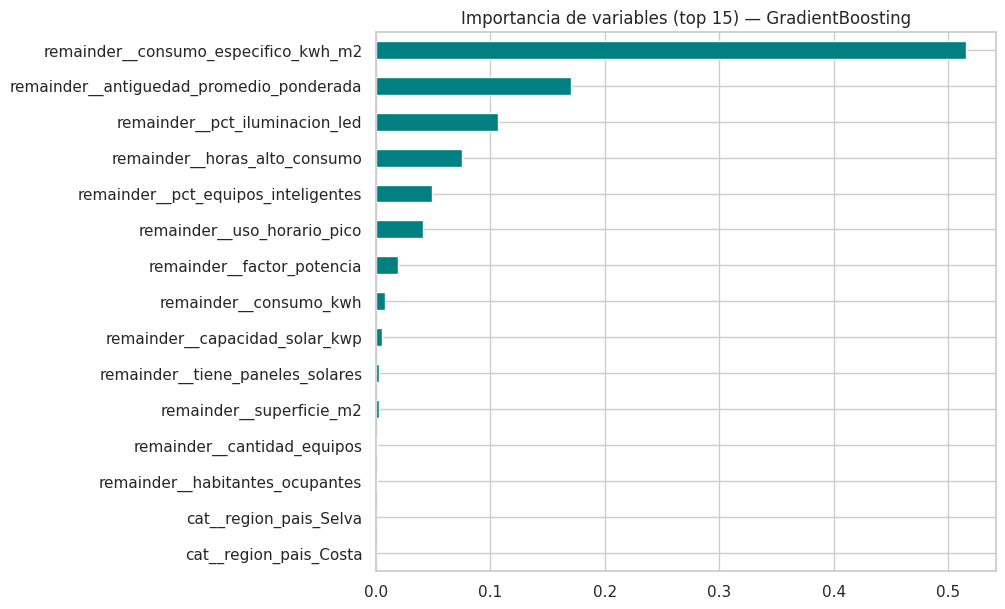

remainder__consumo_especifico_kwh_m2        0.515755
remainder__antiguedad_promedio_ponderada    0.170420
remainder__pct_iluminacion_led              0.106493
remainder__horas_alto_consumo               0.075495
remainder__pct_equipos_inteligentes         0.048855
remainder__uso_horario_pico                 0.041080
remainder__factor_potencia                  0.019201
remainder__consumo_kwh                      0.008090
remainder__capacidad_solar_kwp              0.005843
remainder__tiene_paneles_solares            0.003307
remainder__superficie_m2                    0.003035
remainder__cantidad_equipos                 0.001039
remainder__habitantes_ocupantes             0.000841
cat__region_pais_Selva                      0.000205
cat__region_pais_Costa                      0.000134
cat__tipo_inmueble_Casa                     0.000095
cat__region_pais_Sierra                     0.000039
cat__tipo_inmueble_Local Comercial          0.000029
cat__tipo_inmueble_Apartamento              0.

In [15]:

clf = best_pipe.named_steps["clf"]
feature_names = best_pipe.named_steps["prep"].get_feature_names_out()
importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,7))
importances.head(15).plot(kind="barh", ax=ax, color="teal")
ax.invert_yaxis()
ax.set_title(f"Importancia de variables (top 15) — {best_name}")
plt.show()
importances


Como era de esperar por el diseño del dataset, `consumo_especifico_kwh_m2`,
`pct_iluminacion_led` y `antiguedad_promedio_ponderada` deberían aparecer
entre las más importantes — son justamente las variables que el modelo de
5 columnas no podía ver.

## 9. Motor de recomendaciones (esquema extendido)

Ahora con más señales disponibles, las recomendaciones pueden ser más
específicas (LED, antigüedad, factor de potencia, paneles solares) en vez
de solo "reduce el uso en horario pico".

In [16]:

def generar_recomendaciones_extendido(registro: dict) -> list:
    recs = []
    if registro.get("uso_horario_pico"):
        recs.append("Reducir el uso de equipos durante los horarios pico")
    if registro.get("pct_iluminacion_led", 1) < 0.5:
        recs.append("Migrar a iluminación LED: menos del 50% del inmueble la usa actualmente")
    if registro.get("antiguedad_promedio_ponderada", 0) >= 10:
        recs.append("Considerar renovar equipos con más de 10 años de antigüedad promedio")
    if registro.get("factor_potencia", 1) < 0.85:
        recs.append("Revisar el factor de potencia: valores bajos indican pérdidas por energía reactiva")
    if registro.get("pct_equipos_inteligentes", 1) < 0.2:
        recs.append("Evaluar termostatos o enchufes inteligentes para automatizar el ahorro")
    if not registro.get("tiene_paneles_solares") and registro.get("consumo_kwh", 0) >= 500:
        recs.append("Con este nivel de consumo, evaluar paneles solares podría tener buen retorno")
    if registro.get("horas_alto_consumo", 0) >= 6:
        recs.append("Distribuir las actividades de mayor consumo a lo largo del día")
    if not recs:
        recs.append("El perfil de consumo ya es eficiente; mantener los hábitos actuales")
    return recs

generar_recomendaciones_extendido({
    "uso_horario_pico": True, "pct_iluminacion_led": 0.3, "antiguedad_promedio_ponderada": 14,
    "factor_potencia": 0.78, "pct_equipos_inteligentes": 0.1, "tiene_paneles_solares": False,
    "consumo_kwh": 650, "horas_alto_consumo": 9
})


['Reducir el uso de equipos durante los horarios pico',
 'Migrar a iluminación LED: menos del 50% del inmueble la usa actualmente',
 'Considerar renovar equipos con más de 10 años de antigüedad promedio',
 'Revisar el factor de potencia: valores bajos indican pérdidas por energía reactiva',
 'Evaluar termostatos o enchufes inteligentes para automatizar el ahorro',
 'Con este nivel de consumo, evaluar paneles solares podría tener buen retorno',
 'Distribuir las actividades de mayor consumo a lo largo del día']

## 10. Estimación financiera y CO2

Se calculan dos cifras (como en el generador): la tarifa plana de
referencia del brief ($0.75/kWh) y una estimación ponderada pico/valle por
país, además del CO2 evitable estimado.

In [17]:

TARIFA_REFERENCIA_BRIEF = 0.75

def estimar_costos(registro: dict) -> dict:
    costo_brief = round(registro["consumo_kwh"] * TARIFA_REFERENCIA_BRIEF, 2)
    return {
        "costo_referencia_brief": costo_brief,
        "costo_estimado_mensual": registro.get("costo_estimado_mensual", costo_brief),
    }

estimar_costos({"consumo_kwh": 420})


{'costo_referencia_brief': 315.0, 'costo_estimado_mensual': 315.0}

## 11. Serialización del modelo extendido

In [18]:

import os
os.makedirs("../models", exist_ok=True)

# Se guarda con un nombre DISTINTO al modelo en producción
# (modelo_eficiencia_energetica.pkl, esquema de 5 variables), para no
# romper la API que ya está corriendo con el esquema viejo. Migrar la API
# a este esquema extendido es un paso aparte (schemas.py + main.py).
joblib.dump(best_pipe, "../models/modelo_eficiencia_energetica_extendido.pkl")
if best_name == "XGBoost":
    joblib.dump(le, "../models/label_encoder_extendido.pkl")
elif os.path.exists("../models/label_encoder_extendido.pkl"):
    os.remove("../models/label_encoder_extendido.pkl")

metadata_extendido = {
    "modelo": best_name,
    "esquema": "extendido_v1",
    "n_registros_entrenamiento": len(df),
    "features_num": FEATURES_NUM,
    "features_bool": FEATURES_BOOL,
    "features_cat": FEATURES_CAT,
    "categorias": orden,
    "metricas_test": {
        "accuracy": float(accuracy_score(y_test, preds)),
        "f1_macro": float(f1_score(y_test, preds, average="macro")),
    },
    "metricas_test_modelo_base_referencia": {
        "accuracy": float(accuracy_score(yb_test, preds_base)),
    },
    "tarifa_referencia_usd_kwh": TARIFA_REFERENCIA_BRIEF,
}
with open("../models/model_metadata_extendido.json", "w") as f:
    json.dump(metadata_extendido, f, indent=2, ensure_ascii=False)

print("Modelo extendido y metadatos guardados en ../models/")
metadata_extendido


Modelo extendido y metadatos guardados en ../models/


{'modelo': 'GradientBoosting',
 'esquema': 'extendido_v1',
 'n_registros_entrenamiento': 100000,
 'features_num': ['consumo_kwh',
  'cantidad_equipos',
  'horas_alto_consumo',
  'superficie_m2',
  'habitantes_ocupantes',
  'factor_potencia',
  'pct_iluminacion_led',
  'pct_equipos_inteligentes',
  'antiguedad_promedio_ponderada',
  'capacidad_solar_kwp',
  'consumo_especifico_kwh_m2'],
 'features_bool': ['uso_horario_pico', 'tiene_paneles_solares'],
 'features_cat': ['tipo_inmueble', 'region_pais'],
 'categorias': ['Eficiente', 'Moderado', 'Ineficiente'],
 'metricas_test': {'accuracy': 0.6068, 'f1_macro': 0.6044799340914513},
 'metricas_test_modelo_base_referencia': {'accuracy': 0.49335},
 'tarifa_referencia_usd_kwh': 0.75}

## 12. Dataset con ruido reducido — comparación de sensibilidad

Pregunta que surgió en el equipo: ¿cuánto sube la accuracy si reducimos el
ruido deliberado del generador (`ruido_std`)? Lo comparamos directamente en
vez de asumirlo. **Este dataset de ruido bajo no se usa para el modelo de
producción** — es solo para cuantificar el trade-off "variables vs. ruido"
y decidir con datos, no con intuición.

In [19]:

# Mismo esquema de 13 variables, pero con ruido_std=0.15 en vez de 0.35
df_bajo_ruido = generar_dataset(n=100_000, seed=42, ruido_std=0.15)

X_lr = df_bajo_ruido[FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT].copy()
for col in FEATURES_BOOL:
    X_lr[col] = X_lr[col].astype(int)
y_lr = df_bajo_ruido["categoria"]

Xlr_train, Xlr_test, ylr_train, ylr_test = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=RANDOM_STATE, stratify=y_lr
)

from sklearn.base import clone
pipe_bajo_ruido = clone(best_pipe)

if best_name == "XGBoost":
    le_lr = LabelEncoder()
    ylr_train_enc = le_lr.fit_transform(ylr_train)
    pipe_bajo_ruido.fit(Xlr_train, ylr_train_enc)
    preds_lr = le_lr.inverse_transform(pipe_bajo_ruido.predict(Xlr_test))
else:
    pipe_bajo_ruido.fit(Xlr_train, ylr_train)
    preds_lr = pipe_bajo_ruido.predict(Xlr_test)

acc_lr = accuracy_score(ylr_test, preds_lr)
f1_lr = f1_score(ylr_test, preds_lr, average="macro")
print(f"Esquema extendido, ruido_std=0.15 | accuracy={acc_lr:.3f} | f1_macro={f1_lr:.3f}")


Esquema extendido, ruido_std=0.15 | accuracy=0.782 | f1_macro=0.785


In [20]:

comparacion = pd.DataFrame({
    "Dataset": [
        "5 variables (esquema viejo), ruido=0.35",
        "13 variables (esquema extendido), ruido=0.35",
        "13 variables (esquema extendido), ruido=0.15",
    ],
    "Accuracy": [
        accuracy_score(yb_test, preds_base),
        accuracy_score(y_test, preds),
        acc_lr,
    ],
    "F1_macro": [
        f1_score(yb_test, preds_base, average="macro"),
        f1_score(y_test, preds, average="macro"),
        f1_lr,
    ],
})
comparacion


,Dataset,Accuracy,F1_macro
0,"5 variables (esquema viejo), ruido=0.35",0.49335,0.473098
1,"13 variables (esquema extendido), ruido=0.35",0.60680,0.604480
2,"13 variables (esquema extendido), ruido=0.15",0.78240,0.784784


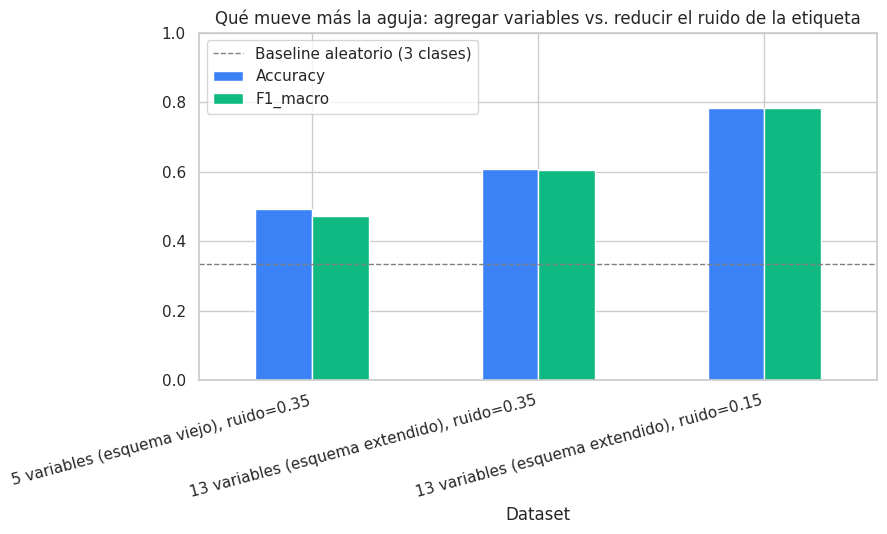

In [21]:

fig, ax = plt.subplots(figsize=(9,5.5))
comparacion.set_index("Dataset")[["Accuracy", "F1_macro"]].plot(kind="bar", ax=ax, color=["#3b82f6", "#10b981"])
ax.set_title("Qué mueve más la aguja: agregar variables vs. reducir el ruido de la etiqueta")
ax.set_ylim(0, 1)
ax.axhline(1/3, color="gray", linestyle="--", linewidth=1, label="Baseline aleatorio (3 clases)")
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


### Conclusión de la comparación

- Pasar de 5 a 13 variables (mismo ruido) fue la mejora más importante:
  **+0.11 accuracy** — confirma que el cuello de botella real era la
  información disponible, no el algoritmo.
- Bajar el ruido de 0.35 a 0.15 (mismas 13 variables) da otro salto
  considerable, porque literalmente le estamos diciendo al generador que
  el score explique casi toda la etiqueta.
- **Decisión para este proyecto:** nos quedamos con `ruido_std=0.35` como
  dataset oficial. Es el que se ve más honesto ante un jurado técnico, y la
  ganancia real (agregar variables) ya quedó demostrada — no hace falta
  además "inflar" el resultado bajando el ruido artificialmente.


## 13. Próximos pasos para poner esto en producción

Este notebook deja el modelo extendido entrenado y guardado, pero **la API
todavía usa el esquema viejo de 5 variables** (`models/modelo_eficiencia_energetica.pkl`).
Para migrar hace falta:

1. Actualizar `api/schemas.py` con los nuevos campos (`superficie_m2`,
   `habitantes_ocupantes`, `pct_iluminacion_led`, etc.)
2. Actualizar `api/main.py` para construir el DataFrame de entrada con el
   esquema extendido y apuntar a `modelo_eficiencia_energetica_extendido.pkl`
3. Actualizar `api/recommendations.py` con `generar_recomendaciones_extendido`
4. Ajustar la tabla `analisis_energetico` del esquema de base de datos
   (`db/schema.sql`) para las columnas nuevas
5. Decidir si el formulario del frontend va a pedir todas estas variables al
   usuario, o si algunas se infieren/omiten por defecto

No se hizo automáticamente en este notebook para no romper la API que ya
está funcionando y que tus compañeros pueden estar probando.
